# Sediment Porosity Workflow (Python)

Python workflow for sediment porosity processing and static inspection plots using NumPy, xarray, rasterio, and Matplotlib.

In [1]:
# georeference the bathymetry from GETM topo.nc and save as GeoTIFF for use in GIS or other mapping tools.

import numpy as np
import rasterio
from rasterio.transform import from_bounds
from rasterio.crs import CRS
from scipy.interpolate import griddata
from pathlib import Path

import matplotlib.pyplot as plt

from datetime import datetime
import os
import pandas as pd
import xarray as xr

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
preproc_indir = Path('/export/lv9/user/qzhan/home/pre-processing/')
setup_indir = Path('/export/lv9/user/qzhan/home/GETM_ERSEM_SETUPS/dws_500m/')
base_dir = Path('/export/lv9/user/qzhan/home/pre-processing/Rivers/dws_500m/')
topo_nc = Path('/export/lv9/user/cgiannopoulos/home/pre-processing/bathymetry_resampling/topo_dws_500m.nc')

rivers_info = setup_indir / 'riverinfo.dat'
output_file = preproc_indir / 'rivers_bfm_20260518_WaddenSea_all_Qing.nc'

print(f'Topo path:   {topo_nc}')
print(f'Final out:   {output_file}')

Topo path:   /export/lv9/user/cgiannopoulos/home/pre-processing/bathymetry_resampling/topo_dws_500m.nc
Final out:   /export/lv9/user/qzhan/home/pre-processing/rivers_bfm_20260518_WaddenSea_all_Qing.nc


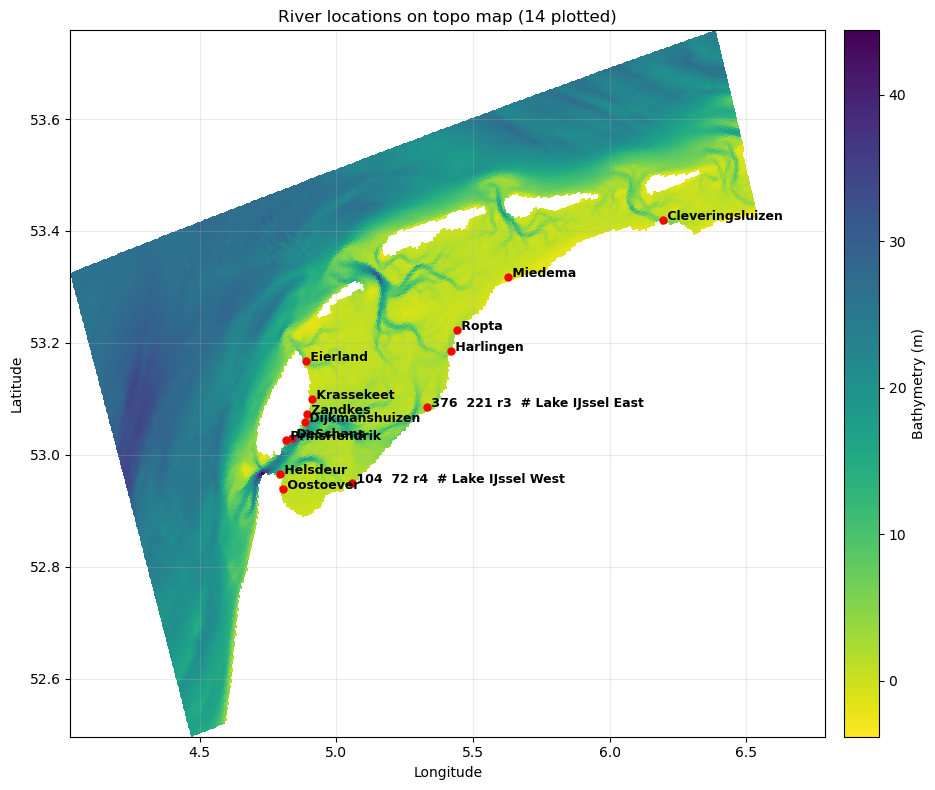

Parsed rivers: 14


In [2]:
# 1. Plot river locations from riverinfo.dat on topo map (xc/yc grid)
river_records = []

with open(rivers_info, "r", encoding="utf-8") as f:
    lines = [ln.rstrip("\n") for ln in f if ln.strip()]

# First non-empty line is expected to contain the number of rivers
try:
    expected_n = int(lines[0].split()[0])
except Exception:
    expected_n = None

for ln in lines[1:]:
    # Split into active tokens and optional human-readable name after '#'.
    active_part, sep, comment_part = ln.partition("#")
    active = active_part.strip()
    if not active:
        continue

    parts = active.split()
    if len(parts) < 3:
        continue

    try:
        xc = int(parts[0])
        yc = int(parts[1])
    except ValueError:
        continue

    river_id = parts[2]
    river_name = comment_part.strip() if sep else ""
    label = river_name if river_name else river_id

    river_records.append({
        "xc": xc,
        "yc": yc,
        "river_id": river_id,
        "river_name": river_name,
        "label": label,
    })

rivers_df = pd.DataFrame(river_records)
if rivers_df.empty:
    raise ValueError(f"No valid river entries parsed from {rivers_file}")

if expected_n is not None and len(rivers_df) != expected_n:
    print(
        f"Warning: expected {expected_n} rivers from header, parsed {len(rivers_df)} valid entries."
    )

ds_topo = xr.open_dataset(topo_nc)

# Use 2D model grid if available; otherwise fall back to index space
if {"lonc", "latc", "bathymetry"}.issubset(ds_topo.variables):
    lon2d = ds_topo["lonc"].values
    lat2d = ds_topo["latc"].values
    bathy = ds_topo["bathymetry"].values

    fig, ax = plt.subplots(figsize=(10, 8))
    mesh = ax.pcolormesh(lon2d, lat2d, bathy, shading="auto", cmap="viridis_r")
    cbar = plt.colorbar(mesh, ax=ax, pad=0.02)
    cbar.set_label("Bathymetry (m)")

    valid_points = 0
    for _, row in rivers_df.iterrows():
        x_idx = int(row["xc"])
        y_idx = int(row["yc"])
        if y_idx < 0 or x_idx < 0 or y_idx >= bathy.shape[0] or x_idx >= bathy.shape[1]:
            print(f"Skipping {row['label']}: index ({x_idx}, {y_idx}) out of bounds")
            continue

        x_lon = float(lon2d[y_idx, x_idx])
        y_lat = float(lat2d[y_idx, x_idx])
        if not np.isfinite(x_lon) or not np.isfinite(y_lat):
            print(f"Skipping {row['label']}: lon/lat is NaN at ({x_idx}, {y_idx})")
            continue

        ax.plot(x_lon, y_lat, "ro", markersize=5)
        ax.text(
            x_lon,
            y_lat,
            f" {row['label']}",
            color="black",
            fontsize=9,
            weight="bold",
        )
        valid_points += 1

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"River locations on topo map ({valid_points} plotted)")
    ax.grid(alpha=0.25)
else:
    # Fallback: plot in model index space if lon/lat variables are not present
    bathy_name = "bathymetry" if "bathymetry" in ds_topo.variables else list(ds_topo.data_vars)[0]
    bathy = ds_topo[bathy_name].values

    fig, ax = plt.subplots(figsize=(10, 8))
    mesh = ax.imshow(bathy, origin="lower", cmap="viridis_r")
    cbar = plt.colorbar(mesh, ax=ax, pad=0.02)
    cbar.set_label(f"{bathy_name}")

    valid_points = 0
    for _, row in rivers_df.iterrows():
        x_idx = int(row["xc"])
        y_idx = int(row["yc"])
        if y_idx < 0 or x_idx < 0 or y_idx >= bathy.shape[0] or x_idx >= bathy.shape[1]:
            print(f"Skipping {row['label']}: index ({x_idx}, {y_idx}) out of bounds")
            continue

        ax.plot(x_idx, y_idx, "ro", markersize=5)
        ax.text(
            x_idx,
            y_idx,
            f" {row['label']}",
            color="black",
            fontsize=9,
            weight="bold",
        )
        valid_points += 1

    ax.set_xlabel("xc index")
    ax.set_ylabel("yc index")
    ax.set_title(f"River locations on topo grid ({valid_points} plotted)")
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

ds_topo.close()
print(f"Parsed rivers: {len(rivers_df)}")

Saved updated rivers NetCDF to: /export/lv9/user/qzhan/home/pre-processing/rivers/rivers_bfm_20200323_WaddenSea_all_Qing.nc
Scaled variables: ['r37', 'r37_N3n', 'r37_N4n', 'r37_N1p']


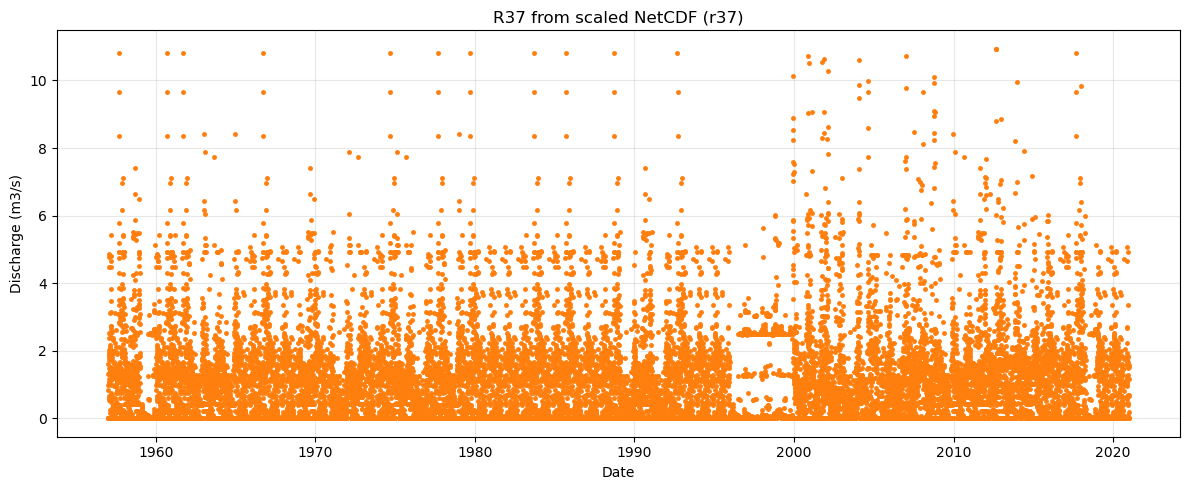

In [7]:
rivers_info = setup_indir / 'riverinfo.dat'
rivers_file = preproc_indir / 'rivers/rivers_bfm_20200323_WaddenSea_all_Sonja.nc'
r37_file = preproc_indir / 'rivers/L0152_HGMiedema_daily_Q_1996_2023.csv'
rivers_outputfile = preproc_indir / 'rivers/rivers_bfm_20200323_WaddenSea_all_Qing.nc'

# 2. Reduce R37 in NetCDF by factor 10, save new file, and plot scaled R37
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt


def _decode_time_to_datetime_index(ds: xr.Dataset, time_name: str = 'time') -> pd.DatetimeIndex:
    """Decode numeric NetCDF time (e.g., 'seconds since 1957-01-01 00:00:00') to pandas datetime."""
    if time_name not in ds.variables:
        raise KeyError(f"'{time_name}' not found in NetCDF variables")

    t = ds[time_name]
    tvals = np.asarray(t.values)
    units = str(t.attrs.get('units', '')).strip().lower()

    if np.issubdtype(tvals.dtype, np.datetime64):
        return pd.to_datetime(tvals)

    # Handle common CF-style units
    if ' since ' in units:
        unit_part, base_part = units.split(' since ', 1)
        base_ts = pd.to_datetime(base_part.strip(), errors='coerce')
        if pd.isna(base_ts):
            raise ValueError(f"Could not parse base time from units: {units}")

        if unit_part.startswith('second'):
            delta = pd.to_timedelta(tvals.astype(float), unit='s')
        elif unit_part.startswith('day'):
            delta = pd.to_timedelta(tvals.astype(float), unit='D')
        elif unit_part.startswith('hour'):
            delta = pd.to_timedelta(tvals.astype(float), unit='h')
        elif unit_part.startswith('minute'):
            delta = pd.to_timedelta(tvals.astype(float), unit='m')
        else:
            raise ValueError(f"Unsupported time unit in: {units}")
        return pd.DatetimeIndex(base_ts + delta)

    # Last-resort parse
    idx = pd.to_datetime(tvals, errors='coerce')
    if idx.isna().all():
        raise ValueError('Could not decode NetCDF time values to datetime')
    return pd.DatetimeIndex(idx)


def _extract_r37_series(ds: xr.Dataset) -> pd.Series:
    """Extract r37 discharge series from NetCDF by variable name containing 'r37' and dimension 'time'."""
    candidates = [
        v for v in ds.data_vars
        if ('r37' in v.lower()) and ('time' in ds[v].dims)
    ]
    if not candidates:
        raise KeyError(
            "No time-dependent variable containing 'r37' found. "
            f"Available data vars: {list(ds.data_vars)}"
        )

    # Prefer 1D time series if available
    candidates_sorted = sorted(candidates, key=lambda v: ds[v].ndim)
    var_name = candidates_sorted[0]
    da = ds[var_name]

    # Reduce extra dims if needed (take first index for non-time dims)
    for dim in da.dims:
        if dim != 'time':
            da = da.isel({dim: 0})

    values = pd.to_numeric(np.asarray(da.values).ravel(), errors='coerce')
    time_index = _decode_time_to_datetime_index(ds, time_name='time')

    n = min(len(time_index), len(values))
    ser = pd.Series(values[:n], index=time_index[:n], name=var_name).dropna()
    return ser


if not rivers_file.exists():
    raise FileNotFoundError(f"Rivers NetCDF file not found: {rivers_file}")

ds_rivers = xr.open_dataset(rivers_file, decode_times=False)

# Scale all data variables that contain r37 by factor 10 reduction
r37_vars = [v for v in ds_rivers.data_vars if 'r37' in v.lower()]
if not r37_vars:
    available = list(ds_rivers.data_vars)
    ds_rivers.close()
    raise KeyError(
        "No variables containing 'r37' found in rivers NetCDF. "
        f"Available data vars: {available}"
    )

ds_out = ds_rivers.copy(deep=True)
for v in r37_vars:
    ds_out[v] = ds_out[v] / 10.0
    ds_out[v].attrs['note'] = 'Scaled by factor 0.1 from source file for R37 adjustment'

rivers_outputfile.parent.mkdir(parents=True, exist_ok=True)
ds_out.to_netcdf(rivers_outputfile)
print(f"Saved updated rivers NetCDF to: {rivers_outputfile}")
print(f"Scaled variables: {r37_vars}")

# Plot scaled r37 from the output file
ds_scaled = xr.open_dataset(rivers_outputfile, decode_times=False)
r37_nc_scaled = _extract_r37_series(ds_scaled)

plt.figure(figsize=(12, 5))
plt.plot(
    r37_nc_scaled.index,
    r37_nc_scaled.values,
    linestyle='None',
    marker='o',
    markersize=2.5,
    color='tab:orange'
 )
plt.xlabel('Date')
plt.ylabel('Discharge (m3/s)')
plt.title(f"R37 from scaled NetCDF ({r37_nc_scaled.name})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

ds_scaled.close()
ds_out.close()
ds_rivers.close()

contextily version: 1.7.0
Target grid: 551 x 251 (lon x lat)
Saved GeoTIFF -> /export/lv9/user/qzhan/home/pre-processing/rivers/topo_georef_500m.tif


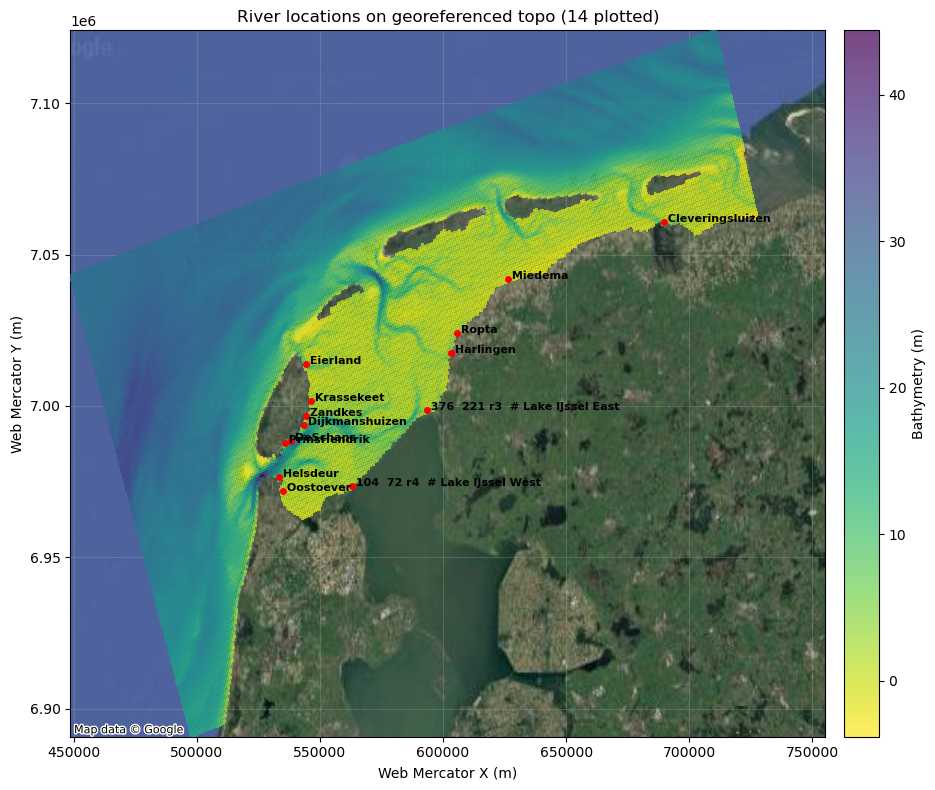

In [12]:
# georeference the bathymetry from GETM topo.nc and plot river locations from riverinfo.dat on the topo map to visually confirm correct georeferencing and river placement.
# and save it as GeoTIFF for use in GIS or other mapping tools.

topo500m_PATH = topo_nc
topo500m_TIFF = preproc_indir / 'rivers/topo_georef_500m.tif'

# Basemap settings (requires internet access and contextily)
USE_BASEMAP = True
BASEMAP_SOURCE = "https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}"  # Google Satellite
BASEMAP_ATTRIBUTION = "Map data © Google"
BASEMAP_ZOOM = 8
BATHY_ALPHA = 0.72

if USE_BASEMAP:
    try:
        import contextily as ctx
        print(f"contextily version: {ctx.__version__}")
    except ImportError as exc:
        raise ImportError(
            "Basemap requested but contextily is not installed. Install with: pip install contextily"
        ) from exc


def _lonlat_to_webmercator(lon: np.ndarray, lat: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    r = 6378137.0
    lon = np.asarray(lon, dtype=float)
    lat = np.asarray(lat, dtype=float)
    lat = np.clip(lat, -85.05112878, 85.05112878)
    x = r * np.deg2rad(lon)
    y = r * np.log(np.tan(np.pi / 4.0 + np.deg2rad(lat) / 2.0))
    return x, y

# Read topo dataset
ds_500m = xr.open_dataset(topo500m_PATH)
lon = ds_500m['lonc'].values          # (yc, xc)
lat = ds_500m['latc'].values          # (yc, xc)
bathy = ds_500m['bathymetry'].values  # (yc, xc)

# Build regular lon/lat grid and interpolate for GeoTIFF output
lon_min, lon_max = float(np.nanmin(lon)), float(np.nanmax(lon))
lat_min, lat_max = float(np.nanmin(lat)), float(np.nanmax(lat))

# Keep roughly the same spatial resolution (~500 m ≈ 0.005 deg)
n_lon = int(np.round((lon_max - lon_min) / 0.005))
n_lat = int(np.round((lat_max - lat_min) / 0.005))
print(f'Target grid: {n_lon} x {n_lat} (lon x lat)')

lon_grid = np.linspace(lon_min, lon_max, n_lon)
lat_grid = np.linspace(lat_min, lat_max, n_lat)
lon2d_reg, lat2d_reg = np.meshgrid(lon_grid, lat_grid)

# ── Interpolate bathymetry onto the regular grid ──────────────────────────────
points = np.column_stack([lon.ravel(), lat.ravel()])
values = bathy.ravel()

# mask out NaN source points
valid = np.isfinite(values)
bathy_reg = griddata(points[valid], values[valid], (lon2d_reg, lat2d_reg), method='linear')

# ── Write GeoTIFF (WGS84) ────────────────────────────────────────────────────
transform = from_bounds(lon_min, lat_min, lon_max, lat_max, n_lon, n_lat)
crs = CRS.from_epsg(4326)
bathy_reg_flipped = np.flipud(bathy_reg)

# Save GeoTIFF
topo500m_TIFF.parent.mkdir(parents=True, exist_ok=True)
with rasterio.open(
    topo500m_TIFF,
    'w',
    driver='GTiff',
    height=n_lat,
    width=n_lon,
    count=1,
    dtype=rasterio.float32,
    crs=crs,
    transform=transform,
    nodata=np.nan,
 ) as dst:
    dst.write(bathy_reg_flipped.astype(np.float32), 1)
    dst.update_tags(description='Bathymetry from GETM topo.nc, WGS84 georeferenced')

print(f'Saved GeoTIFF -> {topo500m_TIFF}')

# Parse river locations from riverinfo.dat (xc/yc index + label after '#')
river_records = []
with open(rivers_info, 'r', encoding='utf-8') as f:
    lines = [ln.rstrip('\n') for ln in f if ln.strip()]

for ln in lines[1:]:
    active_part, sep, comment_part = ln.partition('#')
    active = active_part.strip()
    if not active:
        continue

    parts = active.split()
    if len(parts) < 3:
        continue

    try:
        xc = int(parts[0])
        yc = int(parts[1])
    except ValueError:
        continue

    river_id = parts[2]
    river_name = comment_part.strip() if sep else ''
    label = river_name if river_name else river_id
    river_records.append({'xc': xc, 'yc': yc, 'label': label})

rivers_df = pd.DataFrame(river_records)

# Convert native lon/lat grid to Web Mercator for basemap overlay
x_map, y_map = _lonlat_to_webmercator(lon, lat)

# Plot topo map with river locations and basemap at bottom
fig, ax = plt.subplots(figsize=(10, 8))

finite_xy = np.isfinite(x_map) & np.isfinite(y_map)
if finite_xy.any():
    xlim = (float(np.nanmin(x_map[finite_xy])), float(np.nanmax(x_map[finite_xy])))
    ylim = (float(np.nanmin(y_map[finite_xy])), float(np.nanmax(y_map[finite_xy])))
else:
    xlim = ylim = None

if xlim is not None and ylim is not None:
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

if USE_BASEMAP:
    ctx.add_basemap(
        ax,
        source=BASEMAP_SOURCE,
        crs='EPSG:3857',
        zoom=BASEMAP_ZOOM,
        attribution=BASEMAP_ATTRIBUTION,
        zorder=1,
        reset_extent=False,
    )

mesh = ax.pcolormesh(
    x_map,
    y_map,
    np.ma.masked_invalid(bathy),
    shading='auto',
    cmap='viridis_r',
    alpha=BATHY_ALPHA,
    zorder=3,
 )
cbar = plt.colorbar(mesh, ax=ax, pad=0.02)
cbar.set_label('Bathymetry (m)')

n_plotted = 0
for _, row in rivers_df.iterrows():
    x_idx = int(row['xc'])
    y_idx = int(row['yc'])
    if y_idx < 0 or x_idx < 0 or y_idx >= bathy.shape[0] or x_idx >= bathy.shape[1]:
        continue

    x_lon = float(lon[y_idx, x_idx])
    y_lat = float(lat[y_idx, x_idx])
    if not np.isfinite(x_lon) or not np.isfinite(y_lat):
        continue

    x_pt, y_pt = _lonlat_to_webmercator(np.array([x_lon]), np.array([y_lat]))
    ax.plot(x_pt[0], y_pt[0], 'ro', markersize=4, zorder=5)
    ax.text(x_pt[0], y_pt[0], f" {row['label']}", color='black', fontsize=8, weight='bold', zorder=6)
    n_plotted += 1

if xlim is not None and ylim is not None:
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

ax.set_xlabel('Web Mercator X (m)')
ax.set_ylabel('Web Mercator Y (m)')
ax.set_title(f'River locations on georeferenced topo ({n_plotted} plotted)')
ax.grid(alpha=0.25, zorder=7)
plt.tight_layout()
plt.show()

ds_500m.close()